# BITS M.Tech AIML — Machine Learning Assignment 2


**Student Name:** Jayadeep Male

**BITS ID:** `2025ac05465`  
**Section:** `Section 4`  
**Course:** Machine Learning  
**Assignment:** Assignment 2 — Classification Models  
**Dataset:** Breast Cancer Wisconsin (Diagnostic)

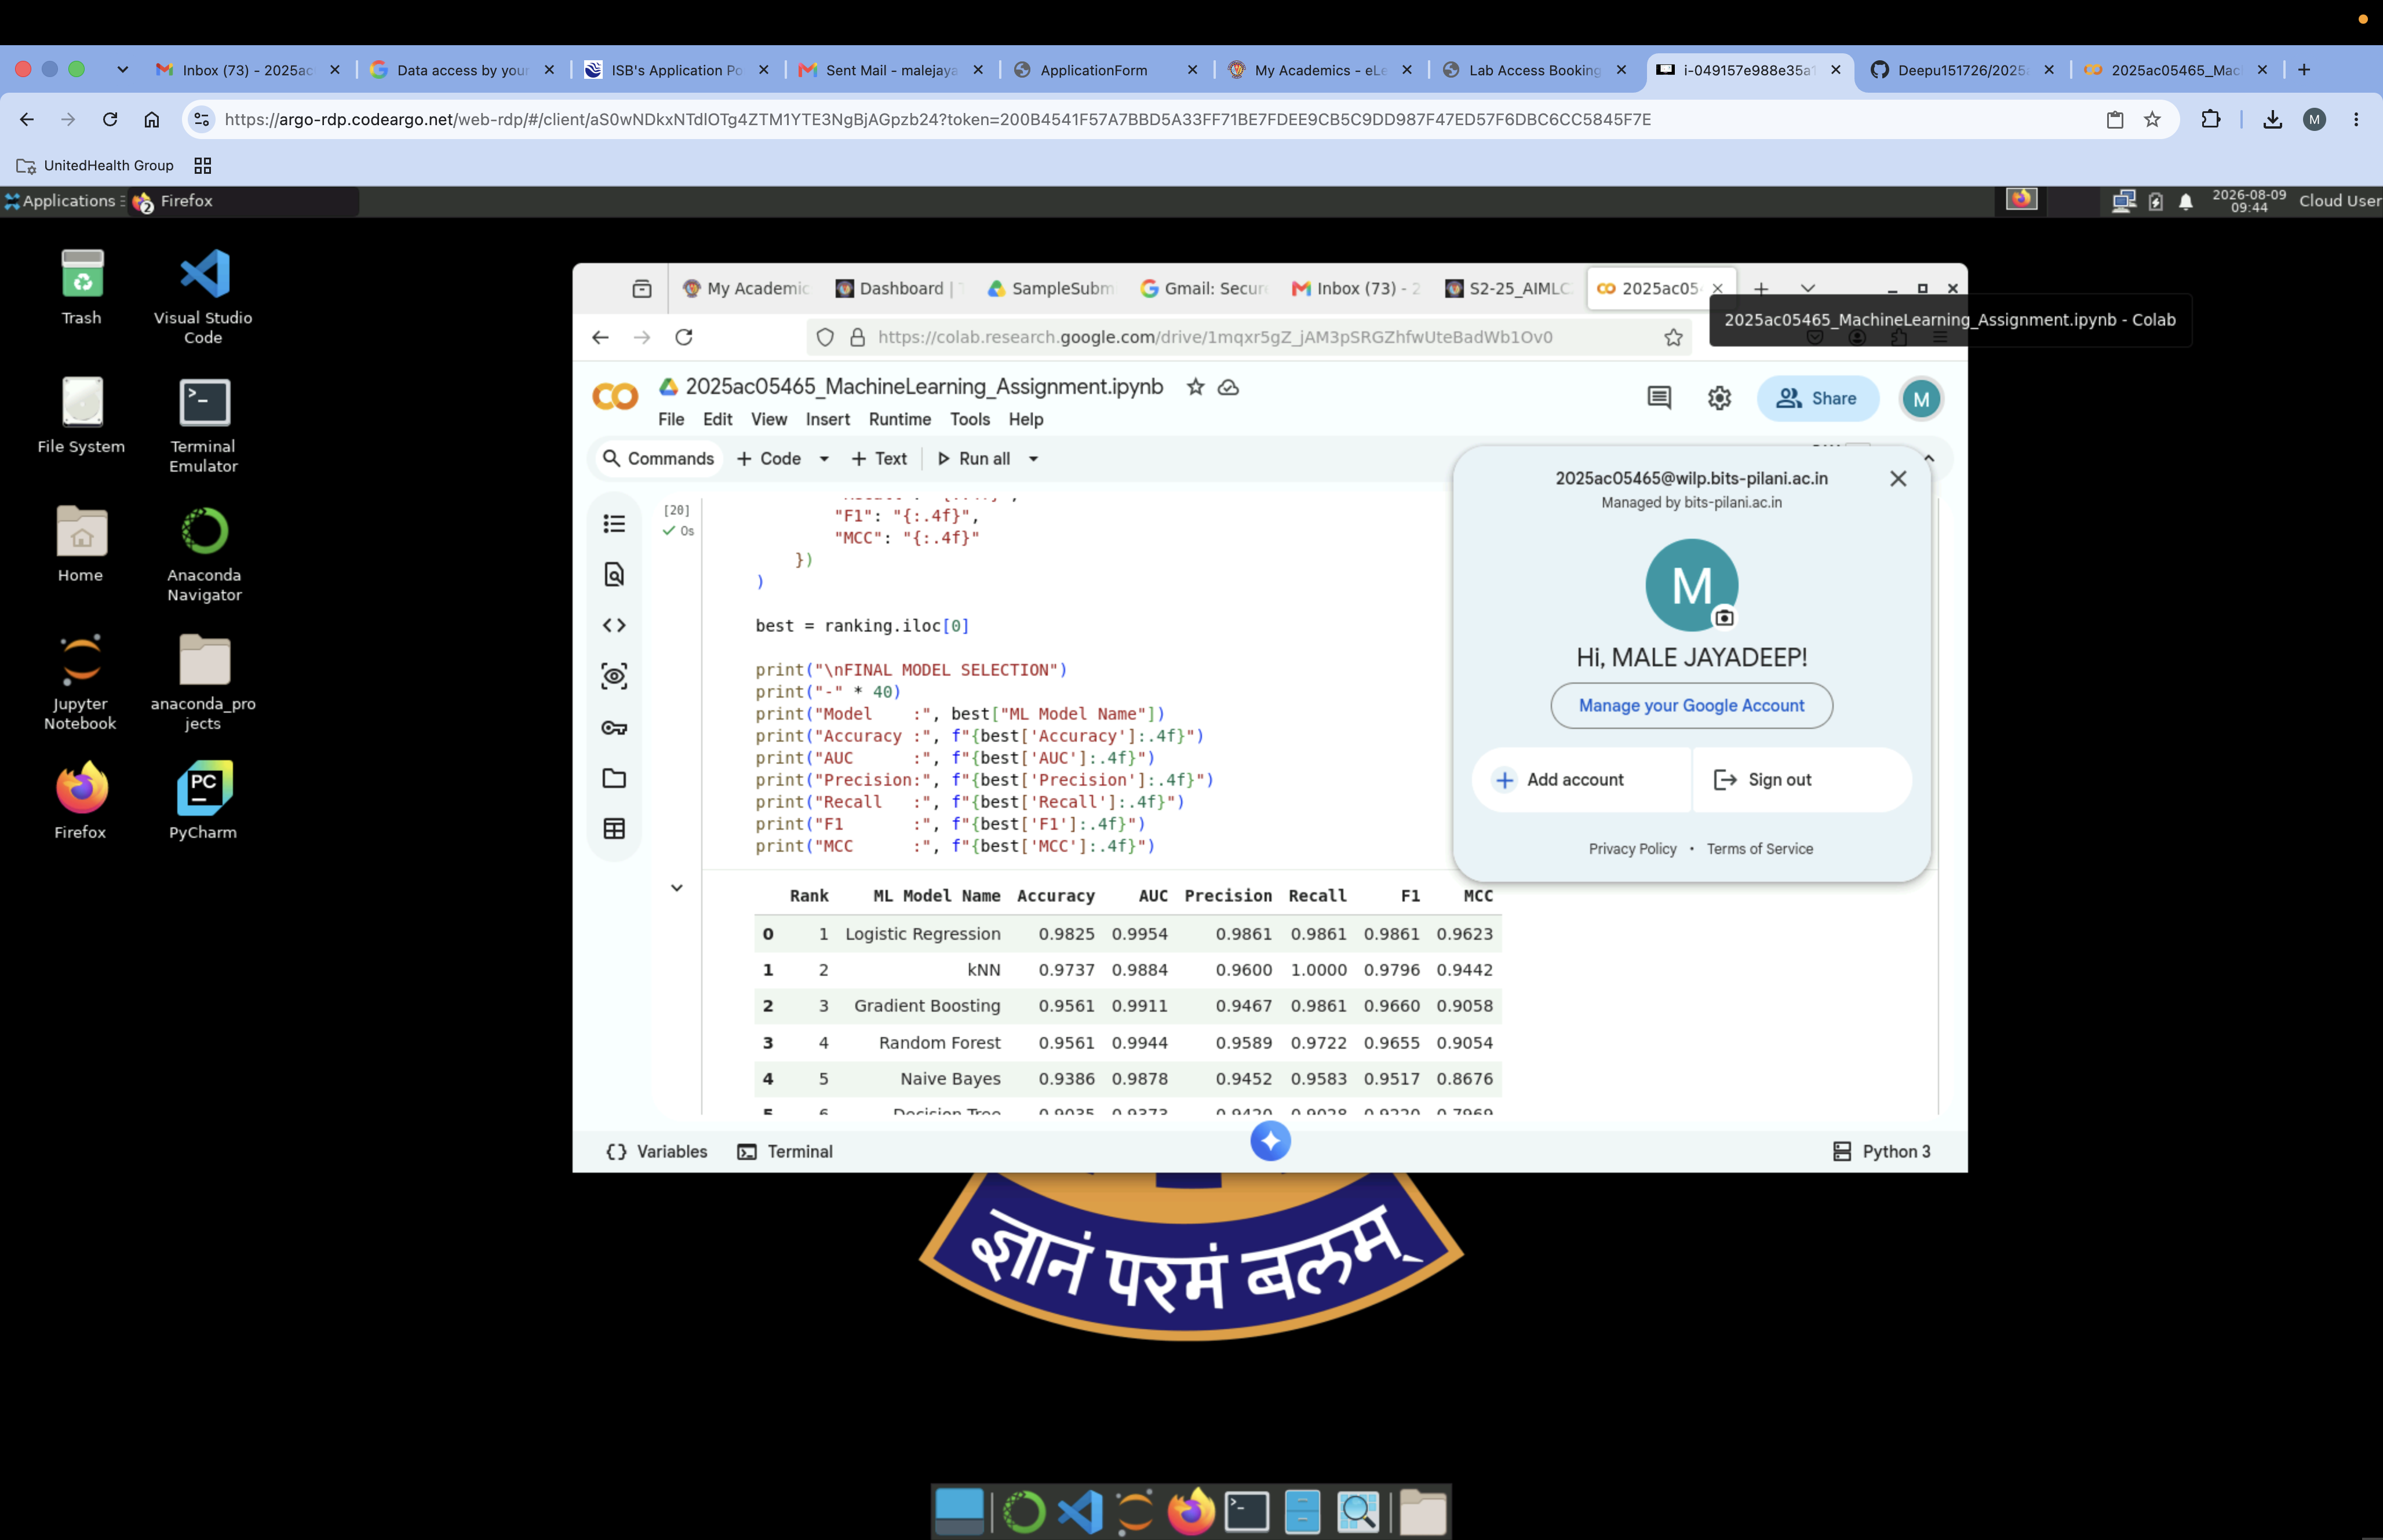

# 1. Problem Statement

The objective of this project is to develop and compare multiple supervised machine-learning classification algorithms on a public binary-classification dataset.

The **Breast Cancer Wisconsin (Diagnostic)** dataset is used to predict whether a breast tumour is **malignant** or **benign** from numerical diagnostic measurements.

The project implements and compares the following six classification algorithms:

1. Logistic Regression
2. Decision Tree
3. k-Nearest Neighbors (kNN)
4. Gaussian Naive Bayes
5. Random Forest
6. Gradient Boosting

Each model is evaluated using the required classification metrics:

- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

The final objective is not only to identify a high-performing classifier, but also to understand how different model families behave on the same dataset and to save the trained models for use in the Streamlit deployment.

# 2. Project Objectives

### Primary objectives

- Understand the dataset and target variable.
- Perform exploratory data analysis before modelling.
- Check data quality, missing values and class distribution.
- Split the dataset using a reproducible stratified train/test split.
- Apply appropriate preprocessing where required.
- Train six different classification algorithms.
- Evaluate all models using the same test set.
- Compare model performance using six metrics.
- Visualize confusion matrices and ROC curves.
- Identify the best-performing model using multiple metrics rather than Accuracy alone.
- Save all trained models as reusable `.joblib` artifacts.
- Generate `test_data.csv`, `train_data.csv` and `metrics.csv` for the Streamlit application and GitHub repository.

# 3. Dataset Description

The **Breast Cancer Wisconsin (Diagnostic)** dataset is a binary classification dataset containing diagnostic measurements computed from digitized images of breast tissue.

### Dataset characteristics

| Property | Description |
|---|---|
| Number of instances | 569 |
| Number of input features | 30 |
| Problem type | Binary classification |
| Target | Malignant / Benign |
| Feature type | Numerical |
| Missing values | None in the sklearn version used here |
| Source | scikit-learn's public copy of the Breast Cancer Wisconsin (Diagnostic) dataset |

The dataset contains measurements such as radius, texture, perimeter, area, smoothness, compactness, concavity, symmetry and fractal dimension, including their mean, standard error and worst-value variants.

### Target encoding

- `0` → malignant
- `1` → benign

The same dataset and test split are used for all six models so that the comparison remains fair and reproducible.

In [ ]:
# ============================================================
# 4. Import Required Libraries
# ============================================================

import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


# 5. Load the Dataset

The dataset is loaded from scikit-learn so the notebook is completely reproducible in Google Colab without requiring a separate manual dataset download.

We convert it into a pandas DataFrame for analysis and modelling.

In [ ]:
# Load dataset
dataset = load_breast_cancer(as_frame=True)

X = dataset.data.copy()
y = dataset.target.copy()

feature_names = list(X.columns)
target_name = "target"

df = X.copy()
df[target_name] = y

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of observations: {X.shape[0]}")
print("\nTarget labels:")
print(dict(enumerate(dataset.target_names)))

display(df.head())

Dataset shape: (569, 31)
Number of features: 30
Number of observations: 569

Target labels:
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Basic dataset inspection

print("Data types:")
display(df.dtypes.to_frame("dtype").T)

print("\nMissing values by column:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values.to_frame("missing_values").T)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(X.describe().T)

Data types:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64



Missing values by column:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
missing_values,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# 6. Exploratory Data Analysis

Before training the models, the dataset is visually and statistically inspected.

The analysis focuses on:

- Class balance
- Feature distributions
- Feature relationships
- Correlation structure
- Potential scale differences between variables

This step helps justify preprocessing decisions and gives context for interpreting model performance.

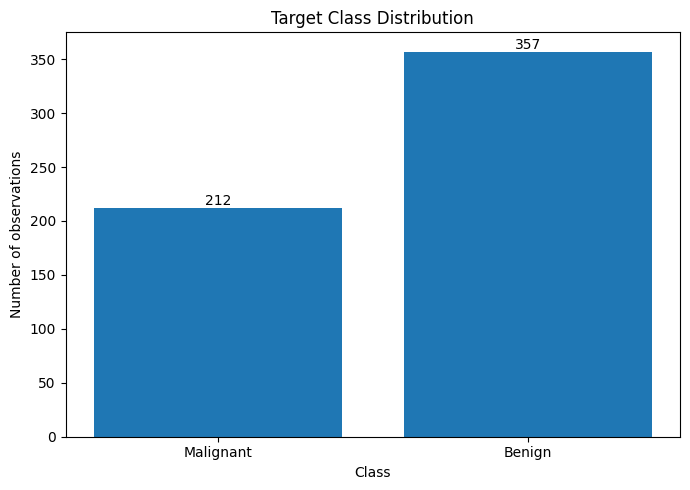

,Class,Count,Percentage
0,Malignant,212,37.26
1,Benign,357,62.74


In [ ]:
# Class distribution

class_counts = y.value_counts().sort_index()
class_labels = ["Malignant", "Benign"]

plt.figure(figsize=(7, 5))
bars = plt.bar(class_labels, class_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of observations")

for bar, value in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

class_percentages = (class_counts / len(y) * 100).round(2)
display(
    pd.DataFrame({
        "Class": class_labels,
        "Count": class_counts.values,
        "Percentage": class_percentages.values
    })
)

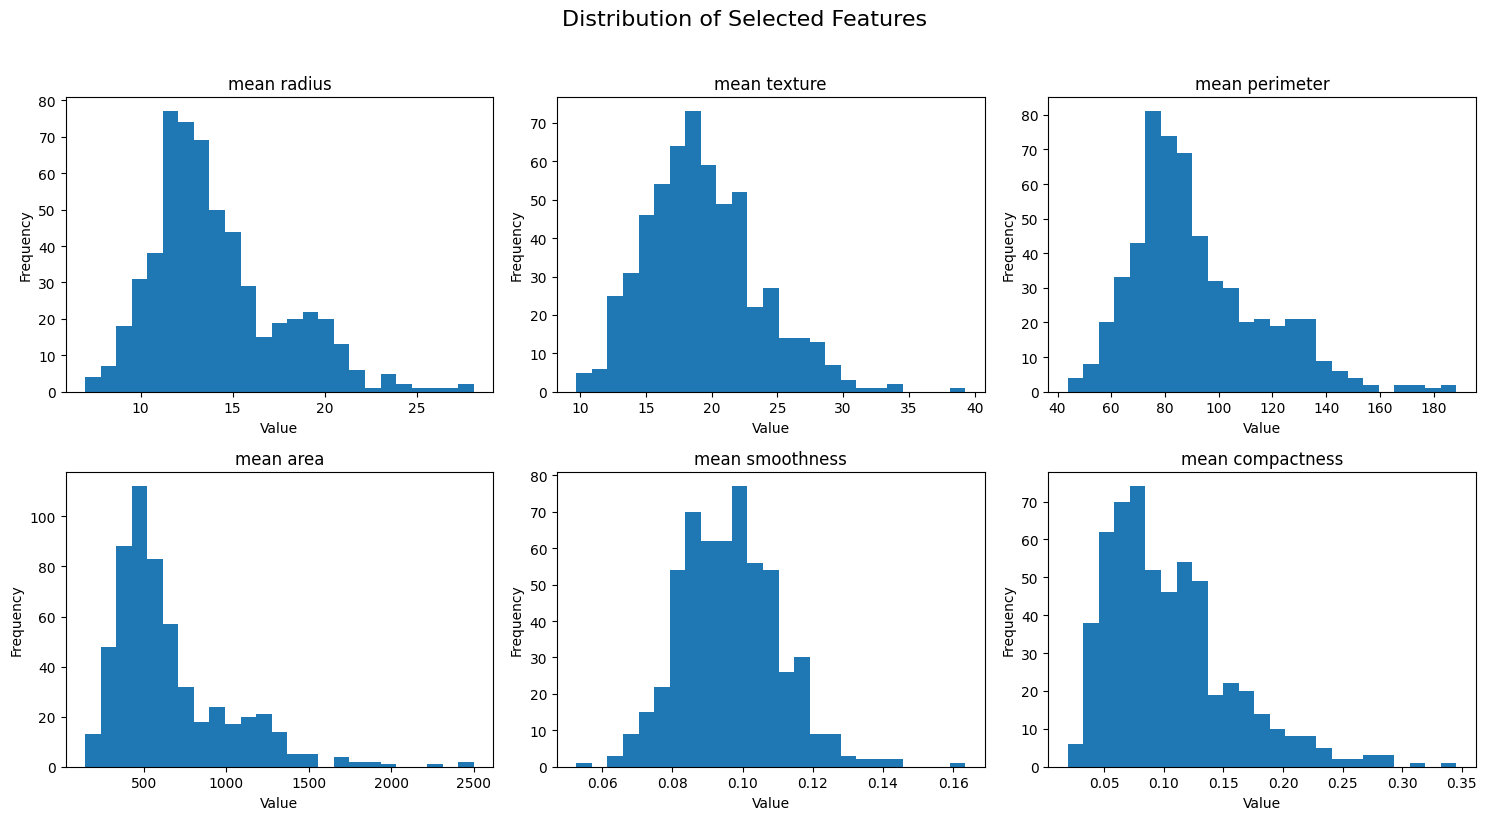

In [ ]:
# Distribution of selected important features

selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.ravel(), selected_features):
    ax.hist(X[feature], bins=25)
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Selected Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

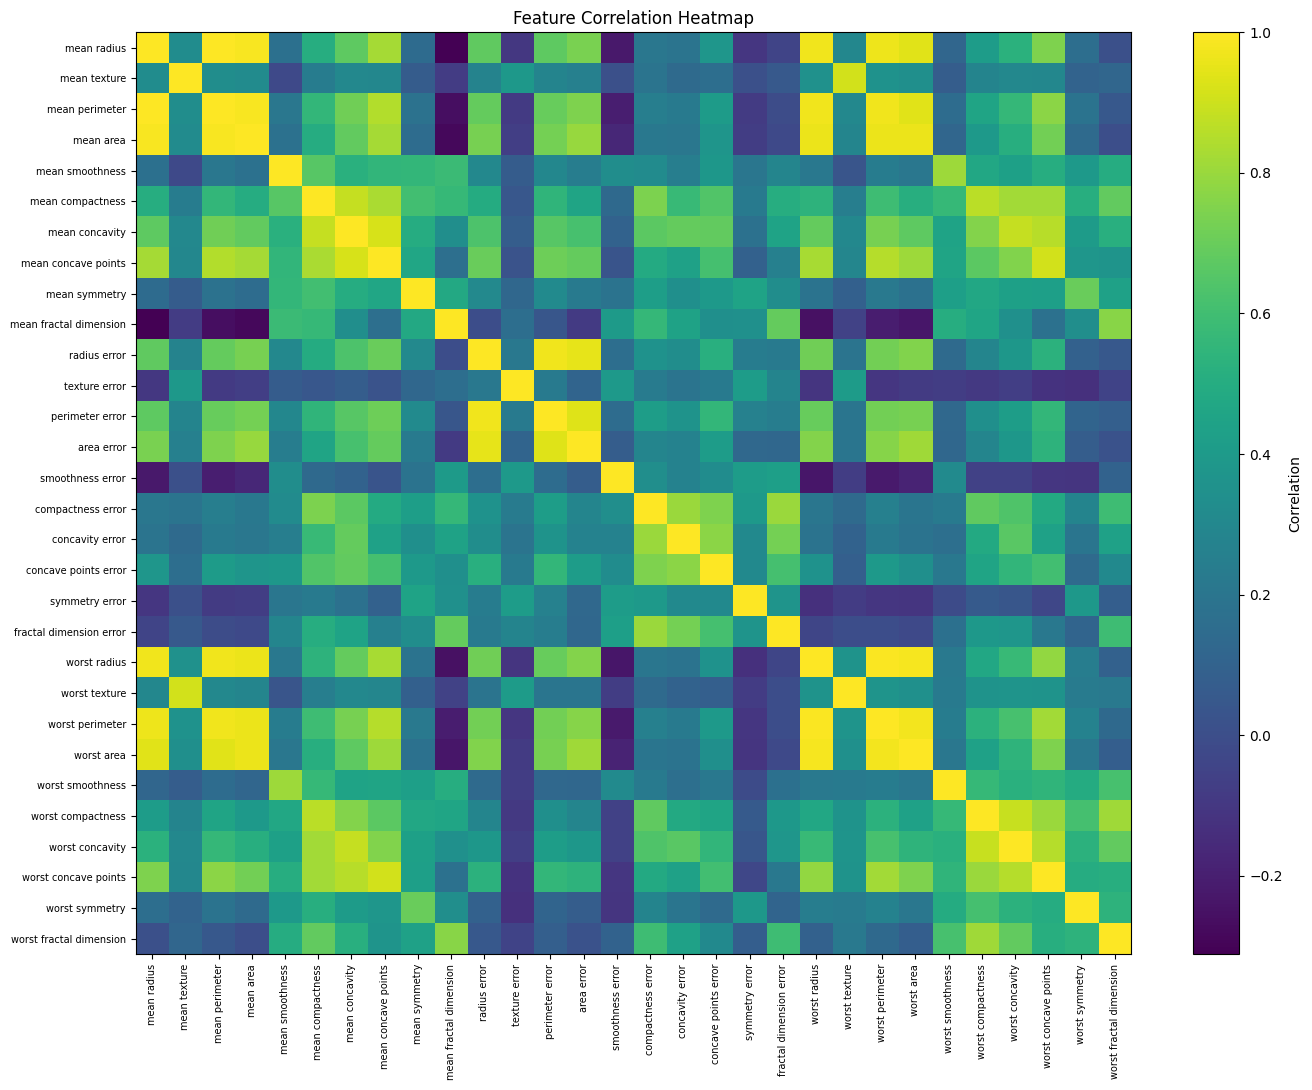

In [ ]:
# Correlation heatmap

corr = X.corr()

plt.figure(figsize=(14, 11))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

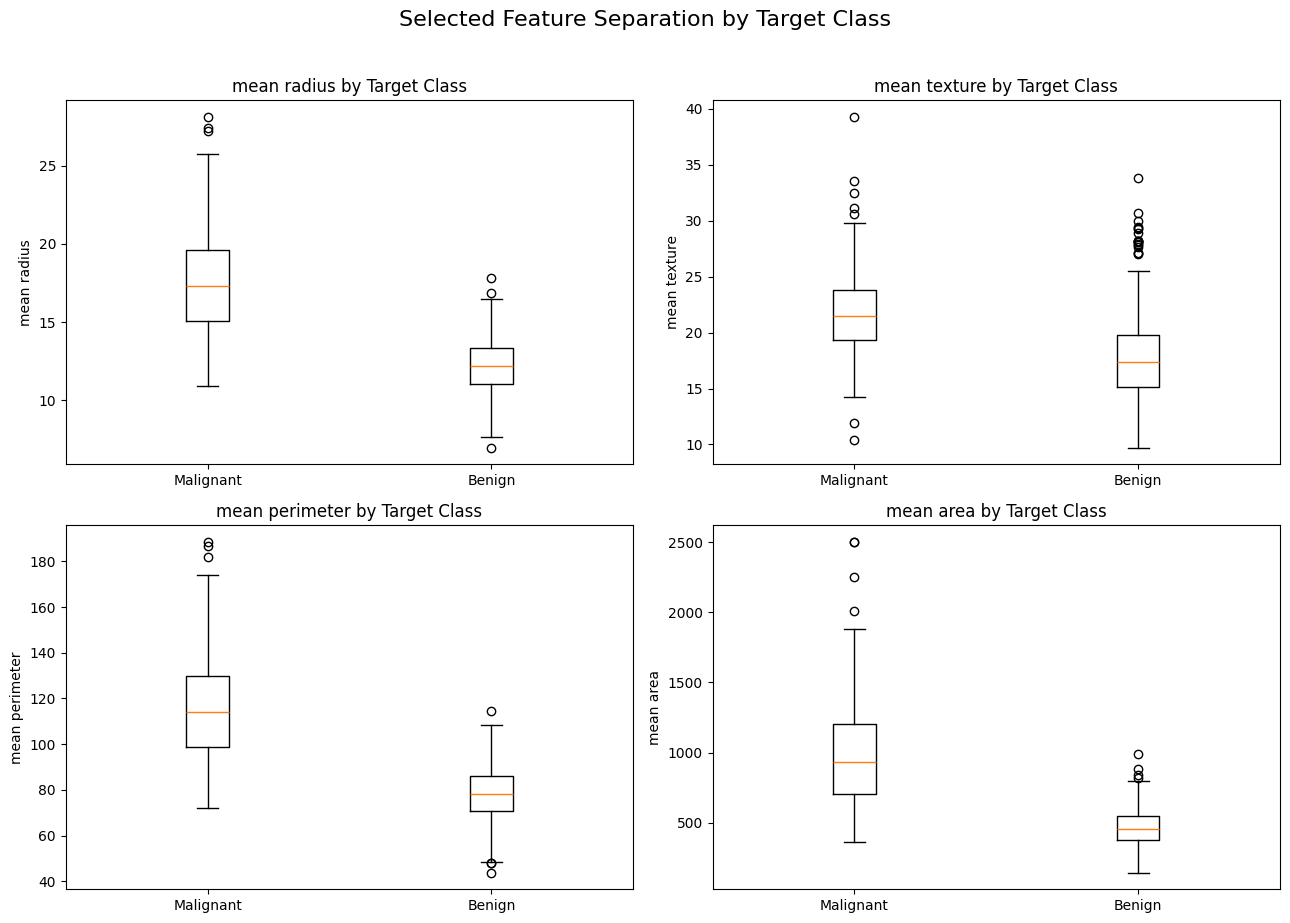

In [ ]:
# Compare selected features by target class

eda_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area"
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feature in zip(axes.ravel(), eda_features):
    ax.boxplot(
        [
            X.loc[y == 0, feature],
            X.loc[y == 1, feature]
        ],
        labels=["Malignant", "Benign"]
    )
    ax.set_title(f"{feature} by Target Class")
    ax.set_ylabel(feature)

plt.suptitle("Selected Feature Separation by Target Class", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# 7. EDA Observations

From the exploratory analysis, the following points can be considered before modelling:

- The target contains two classes, making this a binary classification problem.
- The numerical features have substantially different scales, which is important for distance-based and linear algorithms.
- Several diagnostic variables show meaningful relationships with the target class.
- Many features are strongly correlated with one another because several represent related measurements of the same underlying tumour characteristics.
- Tree-based ensemble models can naturally capture non-linear relationships, while Logistic Regression provides a strong linear baseline.
- kNN is sensitive to feature scale, so standardization is included in its pipeline.

# 8. Train/Test Split

A **stratified 80/20 train/test split** is used.

Stratification preserves approximately the same target-class proportions in the training and test sets. The same split is supplied to every model to ensure a fair comparison.

`random_state = 42` is used for reproducibility.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).sort_index().rename("proportion"))

print("\nTesting class distribution:")
display(y_test.value_counts(normalize=True).sort_index().rename("proportion"))

Training observations: 455
Testing observations: 114

Training class distribution:


,proportion
target,
0,0.373626
1,0.626374



Testing class distribution:


,proportion
target,
0,0.368421
1,0.631579


# 9. Model Configuration

Six classification algorithms are implemented.

### 1. Logistic Regression
A linear probabilistic classifier. Standardization is included in the pipeline.

### 2. Decision Tree
A non-linear rule-based classifier. Tree depth and minimum leaf size are constrained to reduce overfitting.

### 3. kNN
A distance-based classifier. Standardization is essential because the features have different scales.

### 4. Gaussian Naive Bayes
A probabilistic baseline based on conditional independence assumptions.

### 5. Random Forest
An ensemble of randomized decision trees designed to improve robustness and generalization.

### 6. Gradient Boosting
An additive ensemble that sequentially improves weak learners by focusing on residual errors.

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),

    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=7
        ))
    ]),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

print("Models configured:")
for i, model_name in enumerate(models, start=1):
    print(f"{i}. {model_name}")

Models configured:
1. Logistic Regression
2. Decision Tree
3. kNN
4. Naive Bayes
5. Random Forest
6. Gradient Boosting


# 10. Model Training and Evaluation

Each model is trained on exactly the same training data and evaluated on exactly the same test data.

For each model we calculate:

- **Accuracy:** Overall proportion of correct predictions.
- **AUC:** Ability to rank positive and negative examples across classification thresholds.
- **Precision:** Proportion of predicted positives that are actually positive.
- **Recall:** Proportion of actual positives correctly identified.
- **F1:** Harmonic mean of precision and recall.
- **MCC:** Correlation between observed and predicted binary classifications; useful when class sizes differ.

The trained artifacts are also saved as `.joblib` files for the Streamlit application.

In [ ]:
results = []
model_predictions = {}
model_probabilities = {}
trained_models = {}

for model_name, model in models.items():

    print(f"Training {model_name} ...")

    model.fit(X_train, y_train)
    trained_models[model_name] = model

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    model_predictions[model_name] = y_pred
    model_probabilities[model_name] = y_prob

    result = {
        "ML Model Name": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    results.append(result)

    filename = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    joblib.dump(
        {
            "model": model,
            "feature_names": feature_names,
            "target_name": target_name,
            "classes": list(dataset.target_names)
        },
        MODEL_DIR / f"{filename}.joblib"
    )

metrics_df = pd.DataFrame(results)

metrics_df = metrics_df.sort_values(
    by=["F1", "AUC", "MCC"],
    ascending=False
).reset_index(drop=True)

metrics_df.to_csv(MODEL_DIR / "metrics.csv", index=False)

print("\nTraining completed for all six models.")

Training Logistic Regression ...
Training Decision Tree ...
Training kNN ...
Training Naive Bayes ...
Training Random Forest ...
Training Gradient Boosting ...

Training completed for all six models.


In [ ]:
# Final comparison table

display(
    metrics_df.style.format({
        "Accuracy": "{:.4f}",
        "AUC": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "MCC": "{:.4f}"
    })
)

winner = metrics_df.iloc[0]

print(f"\nCurrent overall leader: {winner['ML Model Name']}")
print(f"F1  : {winner['F1']:.4f}")
print(f"AUC : {winner['AUC']:.4f}")
print(f"MCC : {winner['MCC']:.4f}")

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
1,kNN,0.9737,0.9884,0.9600,1.0000,0.9796,0.9442
2,Gradient Boosting,0.9561,0.9911,0.9467,0.9861,0.9660,0.9058
3,Random Forest,0.9561,0.9944,0.9589,0.9722,0.9655,0.9054
4,Naive Bayes,0.9386,0.9878,0.9452,0.9583,0.9517,0.8676
5,Decision Tree,0.9035,0.9373,0.9420,0.9028,0.9220,0.7969



Current overall leader: Logistic Regression
F1  : 0.9861
AUC : 0.9954
MCC : 0.9623


# 11. Visual Model Comparison

The next visualizations compare all six models using the required evaluation metrics.

These plots make it easier to understand whether one model is consistently strong or whether different models trade off precision, recall, ranking ability and overall classification quality.

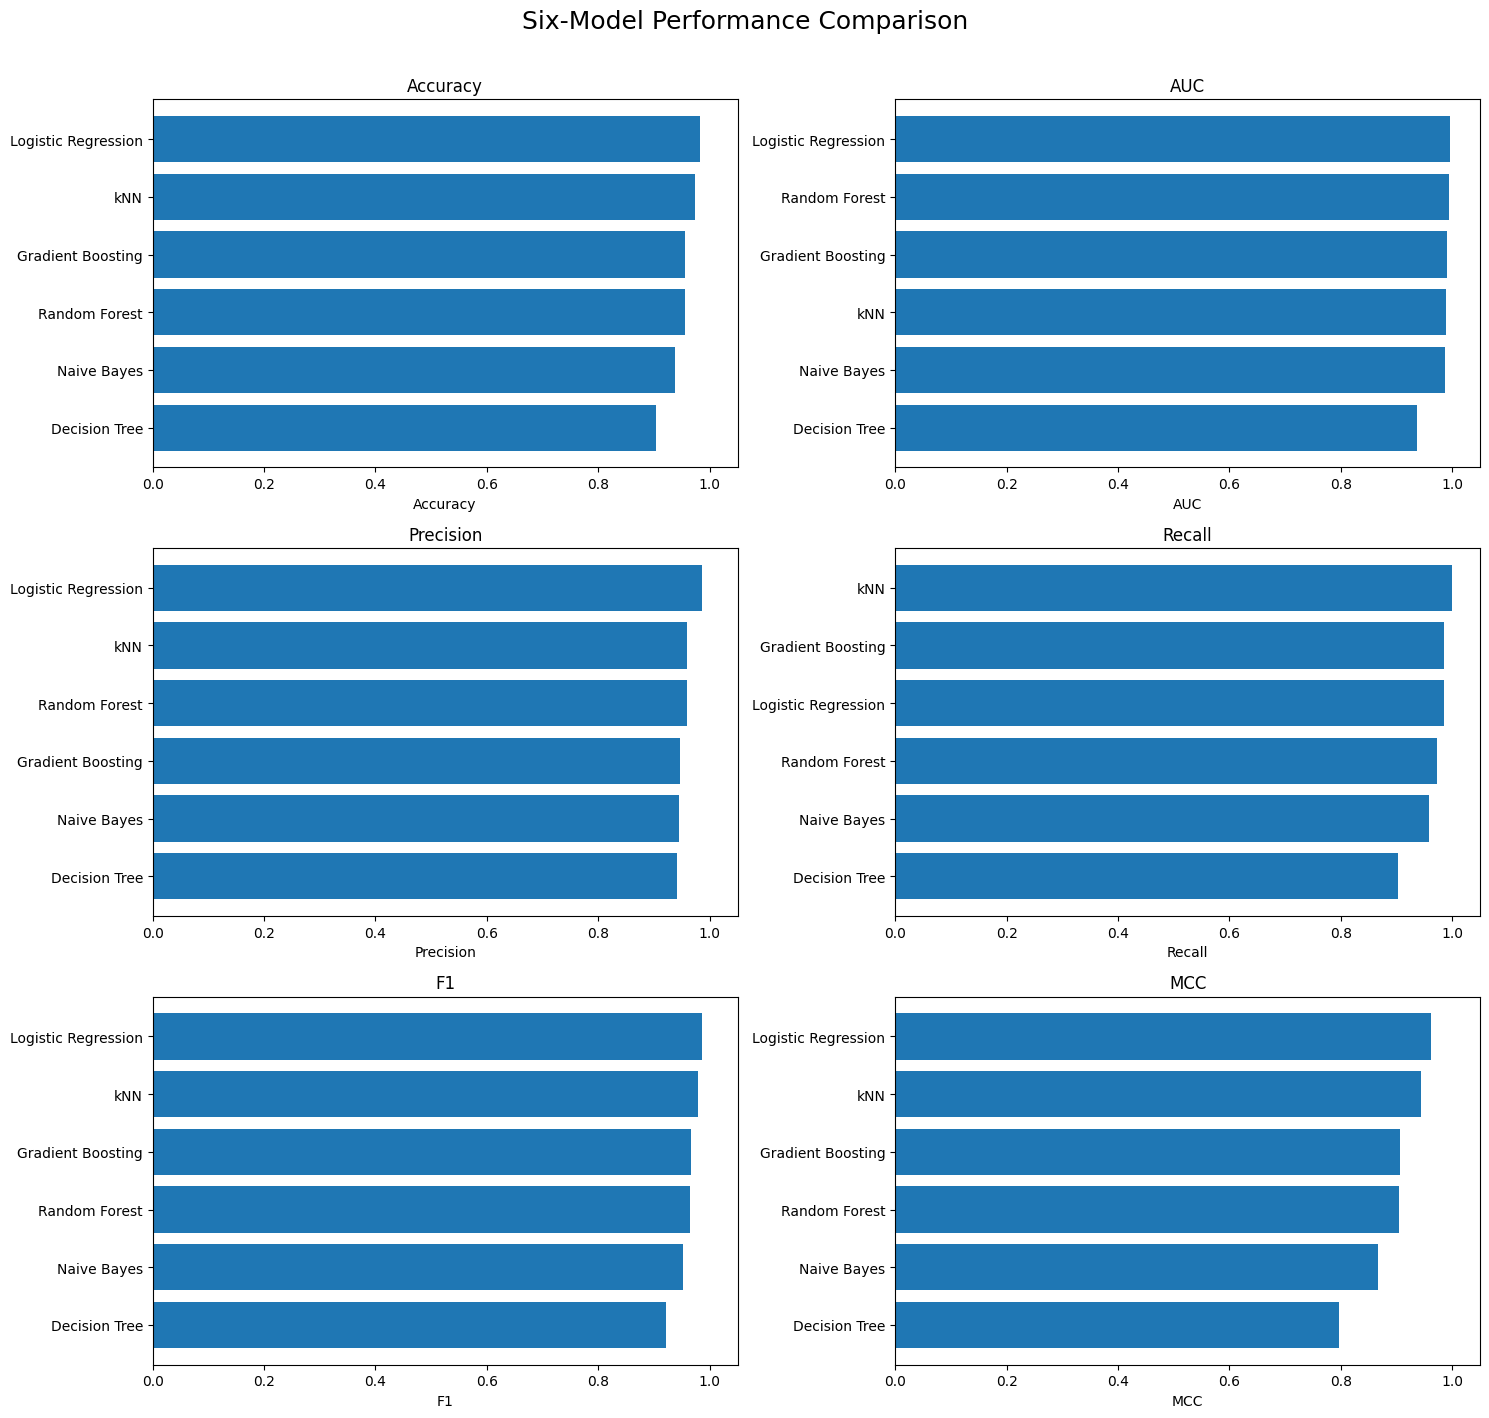

In [ ]:
# Metric comparison chart

plot_metrics = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))

for ax, metric in zip(axes.ravel(), plot_metrics):
    ordered = metrics_df.sort_values(metric, ascending=True)
    ax.barh(ordered["ML Model Name"], ordered[metric])
    ax.set_title(metric)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(metric)

plt.suptitle("Six-Model Performance Comparison", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

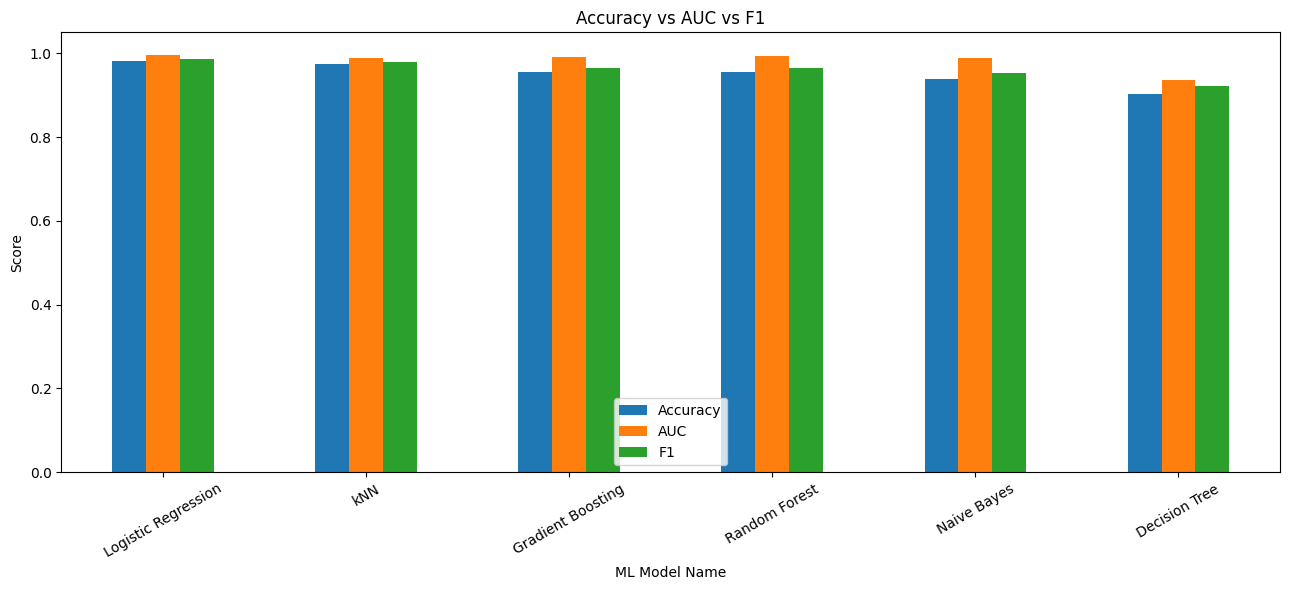

In [ ]:
# Accuracy / F1 / AUC comparison

summary_metrics = metrics_df.set_index("ML Model Name")[
    ["Accuracy", "AUC", "F1"]
]

ax = summary_metrics.plot(
    kind="bar",
    figsize=(13, 6)
)

ax.set_title("Accuracy vs AUC vs F1")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# 12. Confusion Matrix Analysis

A confusion matrix provides a class-by-class view of prediction errors.

For this binary classification task:

- **True Negative (TN):** Malignant sample correctly predicted as malignant.
- **False Positive (FP):** Malignant sample incorrectly predicted as benign.
- **False Negative (FN):** Benign sample incorrectly predicted as malignant.
- **True Positive (TP):** Benign sample correctly predicted as benign.

The class labels follow the dataset encoding: `0 = malignant`, `1 = benign`.

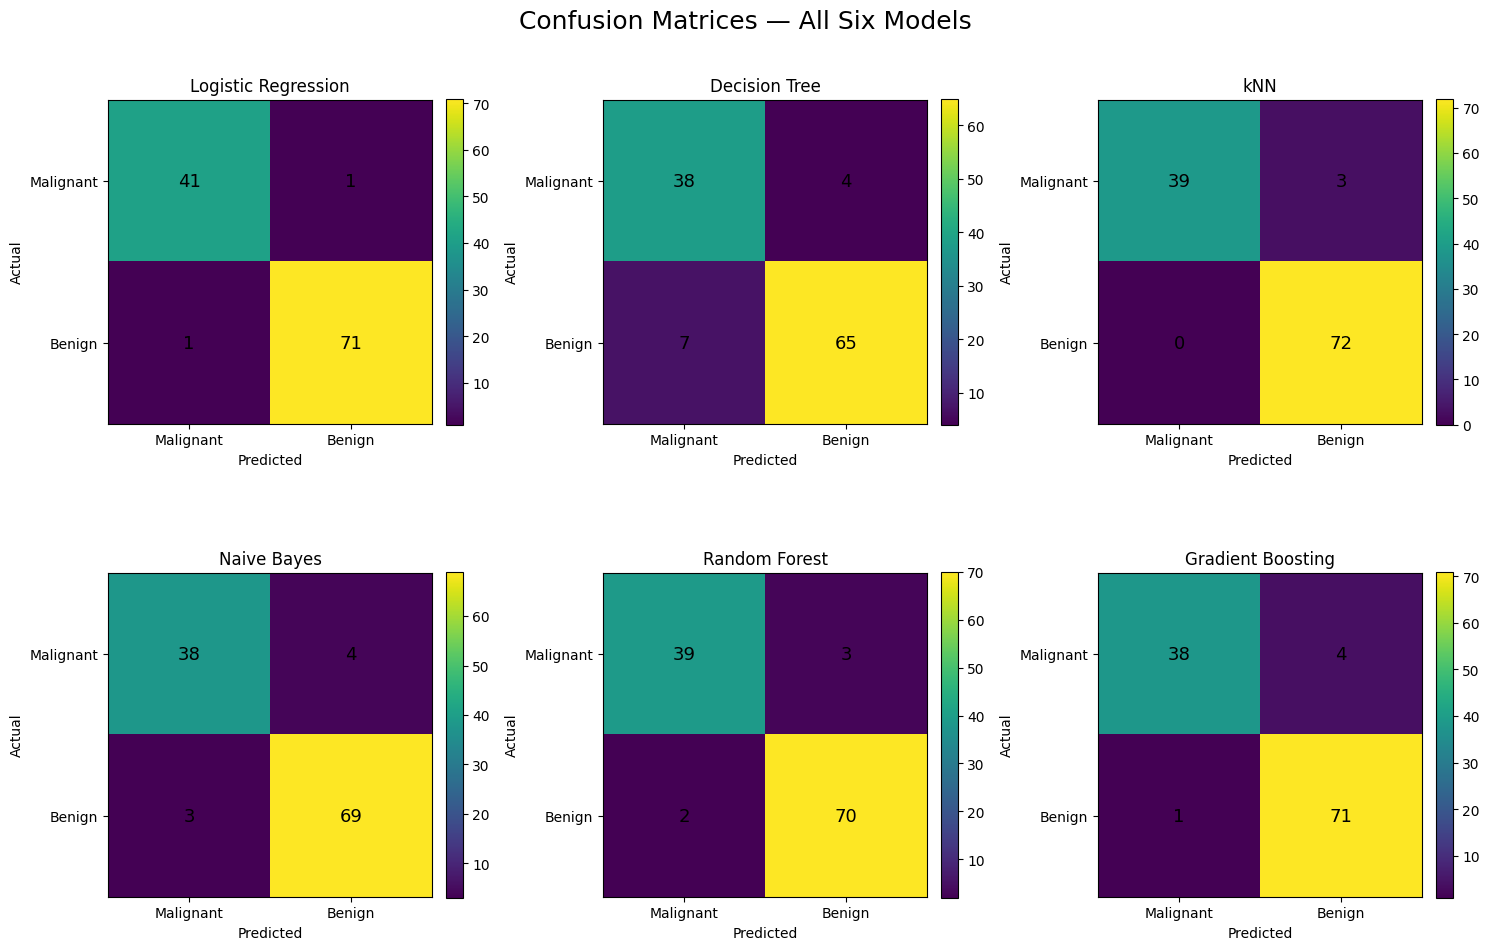

In [ ]:
# Confusion matrices for all six models

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (model_name, predictions) in zip(
    axes.ravel(),
    model_predictions.items()
):
    cm = confusion_matrix(y_test, predictions)

    image = ax.imshow(cm)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["Malignant", "Benign"])
    ax.set_yticks([0, 1], ["Malignant", "Benign"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=13
            )

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Confusion Matrices — All Six Models", fontsize=18)
plt.tight_layout()
plt.show()

# 13. ROC Curve Comparison

The ROC curve evaluates the trade-off between:

- True Positive Rate (Sensitivity / Recall)
- False Positive Rate

The **AUC** summarizes the ranking quality of the classifier across thresholds.

A higher AUC indicates stronger separation between the two classes.

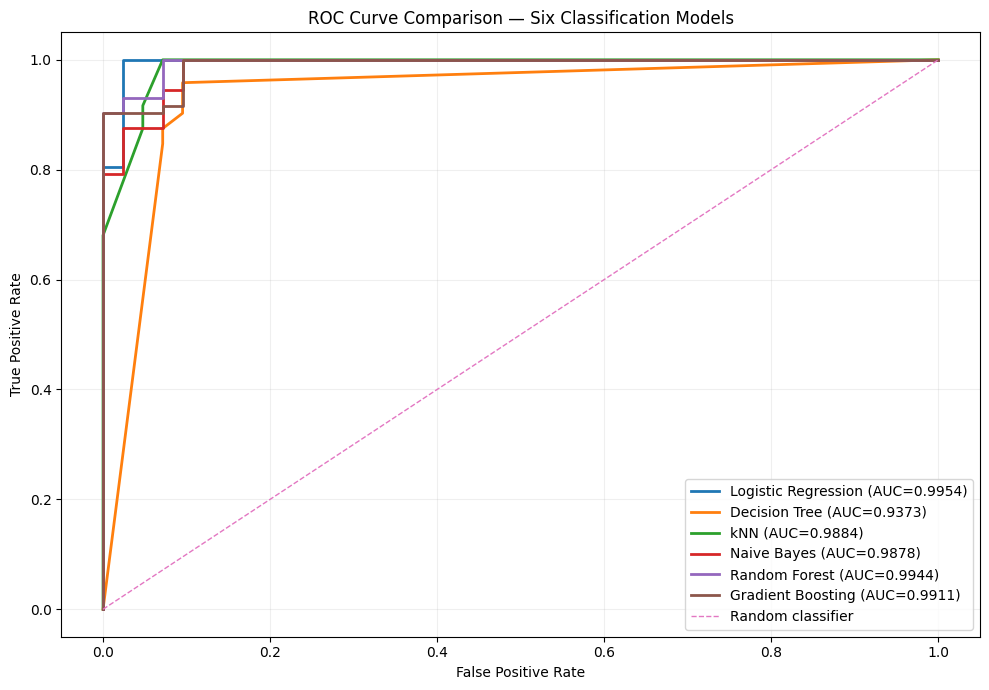

In [ ]:
plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    model_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={model_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Six Classification Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 14. Classification Reports

The classification report gives class-level precision, recall and F1-score.

This is particularly useful because overall Accuracy alone may hide differences in how well the model handles each class.

In [ ]:
for model_name, predictions in model_predictions.items():

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=dataset.target_names,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Decision Tree
              precision    recall  f1-score   support

   malignant       0.84      0.90      0.87        42
      benign       0.94      0.90      0.92        72

    accuracy                           0.90       114
   macro avg       0.89      0.90      0.90       114
weighted avg       0.91      0.90      0.90       114

kNN
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97   

# 15. Feature Importance / Model Interpretability

Tree-based models provide direct feature importance estimates.

This section visualizes feature importance for:

- Random Forest
- Gradient Boosting

The purpose is to identify which diagnostic measurements contributed most strongly to the ensemble's learned decision process.

> Feature importance is model-specific and should not automatically be interpreted as causal importance.

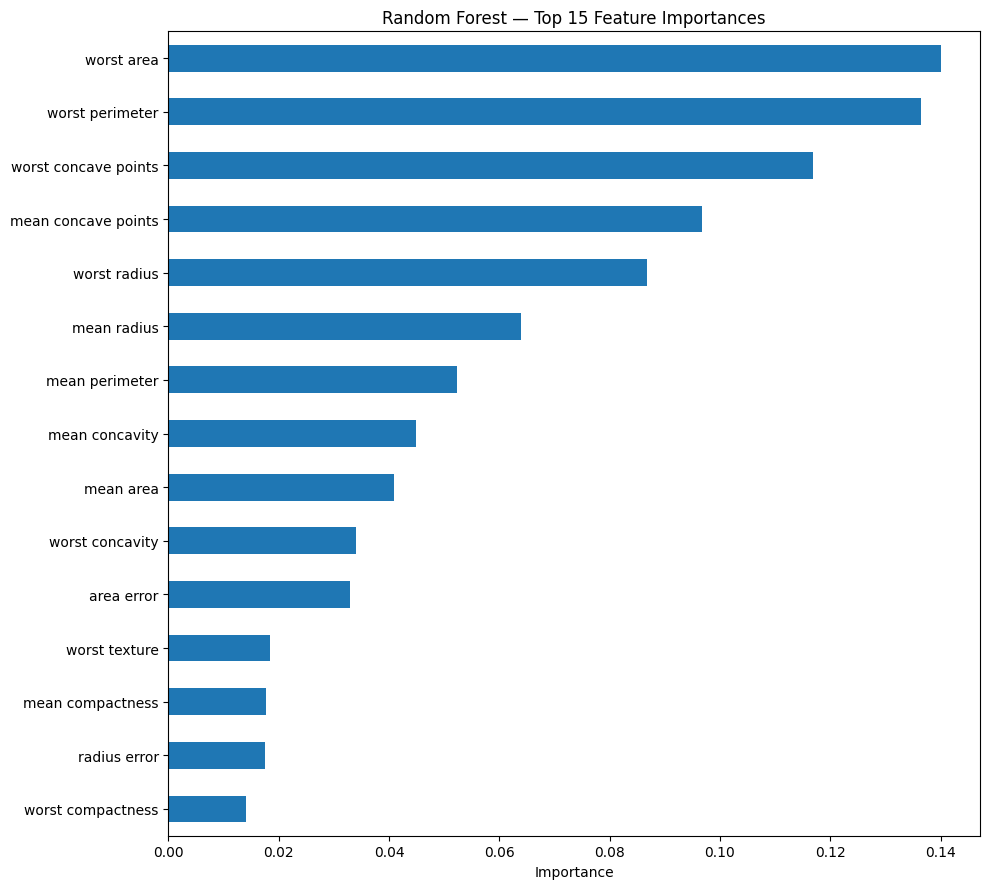

In [ ]:
# Random Forest feature importance

rf = trained_models["Random Forest"]

rf_importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(10, 9))
rf_importance.tail(15).plot(kind="barh")
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

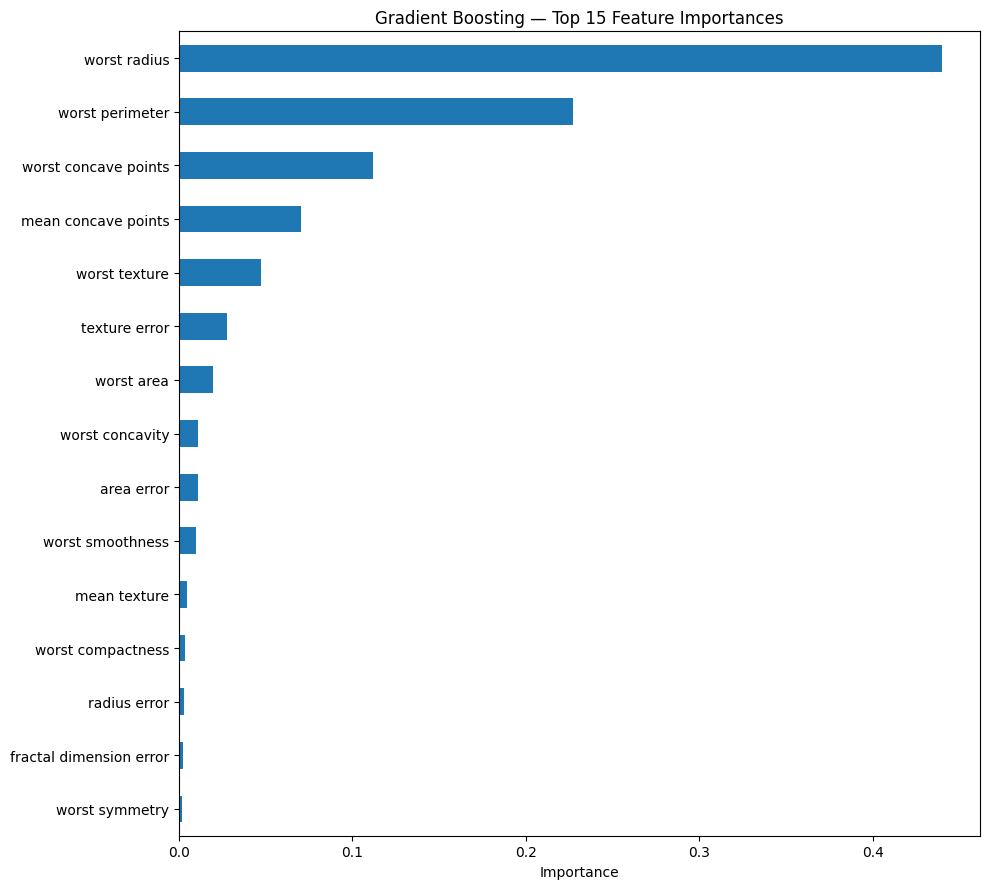

In [ ]:
# Gradient Boosting feature importance

gb = trained_models["Gradient Boosting"]

gb_importance = pd.Series(
    gb.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(10, 9))
gb_importance.tail(15).plot(kind="barh")
plt.title("Gradient Boosting — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 16. Error Analysis

The next section identifies test observations where the model prediction differs from the actual target.

This provides a simple error-analysis layer beyond aggregate metrics and helps identify cases where the classifier struggled.

In [ ]:
# Error analysis for the best model according to the current ranking

best_model_name = metrics_df.iloc[0]["ML Model Name"]

error_analysis = X_test.copy()
error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = model_predictions[best_model_name]
error_analysis["Benign Probability"] = model_probabilities[best_model_name]

error_analysis["Correct"] = (
    error_analysis["Actual"] == error_analysis["Predicted"]
)

errors = error_analysis[~error_analysis["Correct"]].copy()

print("Best model selected for error analysis:", best_model_name)
print("Total test observations:", len(error_analysis))
print("Incorrect predictions:", len(errors))
print(
    "Error rate:",
    f"{len(errors) / len(error_analysis):.2%}"
)

display(
    errors.sort_values(
        "Benign Probability"
    ).head(20)
)

Best model selected for error analysis: Logistic Regression
Total test observations: 114
Incorrect predictions: 2
Error rate: 1.75%


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted,Benign Probability,Correct
541,14.47,24.99,95.81,656.4,0.08837,0.123,0.10090,0.03890,0.1872,0.06341,...,0.1340,0.4202,0.4040,0.1205,0.3187,0.1023,1,0,0.365862,False
73,13.80,15.79,90.43,584.1,0.10070,0.128,0.07789,0.05069,0.1662,0.06566,...,0.1411,0.3542,0.2779,0.1383,0.2589,0.1030,0,1,0.908728,False


# 17. Final Model Selection

The model should not be selected solely from one metric.

For this project, the comparison emphasizes:

- Accuracy
- AUC
- F1
- MCC
- Precision/Recall balance
- Confusion-matrix behaviour

The final winner is the model ranked highest using the combined ordering of **F1 → AUC → MCC** in the generated comparison table.

This selection rule is transparent and reproducible.

In [ ]:
# Final model selection summary

ranking = metrics_df.copy()
ranking.insert(0, "Rank", range(1, len(ranking) + 1))

display(
    ranking.style.format({
        "Accuracy": "{:.4f}",
        "AUC": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "MCC": "{:.4f}"
    })
)

best = ranking.iloc[0]

print("\nFINAL MODEL SELECTION")
print("-" * 40)
print("Model    :", best["ML Model Name"])
print("Accuracy :", f"{best['Accuracy']:.4f}")
print("AUC      :", f"{best['AUC']:.4f}")
print("Precision:", f"{best['Precision']:.4f}")
print("Recall   :", f"{best['Recall']:.4f}")
print("F1       :", f"{best['F1']:.4f}")
print("MCC      :", f"{best['MCC']:.4f}")

,Rank,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,1,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
1,2,kNN,0.9737,0.9884,0.9600,1.0000,0.9796,0.9442
2,3,Gradient Boosting,0.9561,0.9911,0.9467,0.9861,0.9660,0.9058
3,4,Random Forest,0.9561,0.9944,0.9589,0.9722,0.9655,0.9054
4,5,Naive Bayes,0.9386,0.9878,0.9452,0.9583,0.9517,0.8676
5,6,Decision Tree,0.9035,0.9373,0.9420,0.9028,0.9220,0.7969



FINAL MODEL SELECTION
----------------------------------------
Model    : Logistic Regression
Accuracy : 0.9825
AUC      : 0.9954
Precision: 0.9861
Recall   : 0.9861
F1       : 0.9861
MCC      : 0.9623


# 18. Save Training/Test Data and Model Metadata

The following files are generated for the GitHub repository and Streamlit deployment:

- `train_data.csv`
- `test_data.csv`
- `dataset_info.csv`
- `model/metrics.csv`
- six `.joblib` model files

The saved model artifacts contain the trained estimator, feature names, target name and class labels.

In [ ]:
# Save train/test datasets

train_output = X_train.copy()
train_output[target_name] = y_train.values
train_output.to_csv("train_data.csv", index=False)

test_output = X_test.copy()
test_output[target_name] = y_test.values
test_output.to_csv("test_data.csv", index=False)

# Dataset metadata
dataset_info = pd.DataFrame({
    "Property": [
        "Dataset",
        "Instances",
        "Features",
        "Problem Type",
        "Target Encoding",
        "Train Size",
        "Test Size",
        "Random State"
    ],
    "Value": [
        "Breast Cancer Wisconsin (Diagnostic)",
        X.shape[0],
        X.shape[1],
        "Binary Classification",
        "0 = malignant, 1 = benign",
        len(X_train),
        len(X_test),
        RANDOM_STATE
    ]
})

dataset_info.to_csv("dataset_info.csv", index=False)

print("Saved:")
print("- train_data.csv")
print("- test_data.csv")
print("- dataset_info.csv")
print("- model/metrics.csv")

Saved:
- train_data.csv
- test_data.csv
- dataset_info.csv
- model/metrics.csv


In [ ]:
# Verify every required model artifact

required_model_files = [
    "logistic_regression.joblib",
    "decision_tree.joblib",
    "knn.joblib",
    "naive_bayes.joblib",
    "random_forest.joblib",
    "gradient_boosting.joblib"
]

print("MODEL ARTIFACT VERIFICATION")
print("=" * 50)

all_present = True

for filename in required_model_files:
    path = MODEL_DIR / filename
    exists = path.exists()
    all_present &= exists
    print(f"{'OK' if exists else 'MISSING':8} {path}")

print("All six model artifacts available:", all_present)

MODEL ARTIFACT VERIFICATION
OK       model/logistic_regression.joblib
OK       model/decision_tree.joblib
OK       model/knn.joblib
OK       model/naive_bayes.joblib
OK       model/random_forest.joblib
OK       model/gradient_boosting.joblib
All six model artifacts available: True


## Final Conclusion

Six classification models were evaluated using Accuracy, AUC, Precision, Recall, F1 Score, and MCC. Among all models, **Logistic Regression performed the best**, achieving **98.25% Accuracy, 0.9954 AUC, 98.61% Precision, 98.61% Recall, 98.61% F1 Score, and 0.9623 MCC**.

Therefore, **Logistic Regression is selected as the final model** because it provided the best overall and most consistent performance across the evaluation metrics. The trained models were saved as `.joblib` files for further use in the Streamlit application.
